In [1]:
%cd ../
%load_ext autoreload
%autoreload 2

/Users/matthaei/Documents/code/python/bachelor-project


In [2]:
MIGRATE_DATABASE = False

In [3]:
from src.measurements.measurement_service import MeasurementService
from src.weather_stations.weather_station_service import WeatherStationService
from src.wind_turbines.wind_turbines_service import WindTurbinesService
from src.calculation.calculation_service import CalculationService
from src.model.variant.bilstm_model import BiLSTMModel
from src.prediction.prediction_service import PredictionService
from src.database.database_service import DatabaseService
from src.model.model_service import ModelService
from omegaconf import DictConfig, OmegaConf
from hydra import compose, initialize_config_dir
import os
from datetime import datetime
import numpy as np

/Users/matthaei/Documents/code/python/bachelor-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Initialize Hydra configuration
config_dir = os.path.abspath("./conf")

# Initialize Hydra with the config directory
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")

In [5]:
database_service = DatabaseService(cfg)

if MIGRATE_DATABASE:
    database_service.create_tables()

In [6]:
weather_station_service = WeatherStationService(cfg, database_service)
weather_stations_df = weather_station_service.load_from_database()

2025-09-17 10:13:41.886 | INFO     | src.weather_stations.weather_station_data_provider:load_from_database:236 - Loaded 32 weather stations from database


In [7]:
measurement_service = MeasurementService(cfg, database_service, weather_stations_df)

In [8]:
model_service = ModelService(cfg, database_service, measurement_service)

In [9]:
lstm = BiLSTMModel()

In [10]:
lstm.load('models/good_lstm/')

In [11]:
model_service.attach_model(lstm)

## Get Predictions


In [12]:
prediction_service = PredictionService(cfg, database_service, measurement_service, model_service)

In [13]:
measurements_df = prediction_service.predict_measurements()

2025-09-17 10:13:51.367 | INFO     | src.measurements.measurement_service:load_all_recent_measurements_from_database:130 - Loading all recent measurements from database
2025-09-17 10:13:51.672 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:246 - Loaded chunk of 2304 rows (total so far: 2304)
2025-09-17 10:13:51.719 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:255 - Loaded 2304 measurements from database
2025-09-17 10:13:51.719 | INFO     | src.measurements.measurement_service:load_all_recent_measurements_from_database:132 - Loaded 2304 recent measurements from database
2025-09-17 10:13:52.172 | INFO     | src.prediction.prediction_data_provider:save_predictions_to_database:56 - Upserted 200 predictions to database
2025-09-17 10:13:52.265 | INFO     | src.prediction.prediction_data_provider:save_predictions_to_database:56 - Upserted 200 predictions to database
2025-09-17 10:13:52.347 | INFO     | src.pre

In [14]:
measurements_df

,station_id,record_date,u,v,is_prediction
0,96,2025-09-16 19:40:00,3.464102,2.000000,False
72,164,2025-09-16 19:40:00,2.255262,0.820848,False
144,303,2025-09-16 19:40:00,3.348346,-0.590404,False
216,427,2025-09-16 19:40:00,4.333154,-0.764052,False
288,433,2025-09-16 19:40:00,4.234673,-0.746687,False
...,...,...,...,...,...
2663,6253,2025-09-17 19:30:00,-0.597450,-0.741531,True
2735,6265,2025-09-17 19:30:00,1.442894,1.404416,True
2807,7351,2025-09-17 19:30:00,-0.588203,-0.731586,True
2879,7389,2025-09-17 19:30:00,-0.499611,-0.637241,True


In [14]:
na_count = measurements_df.isna().sum()
na_count

station_id       0
record_date      0
u                0
v                0
is_prediction    0
dtype: int64

In [15]:
single_station_df = measurements_df[measurements_df["station_id"] == 96]

single_station_df

,station_id,record_date,u,v,is_prediction
0,96,2025-09-16 19:40:00,3.464102,2.000000,False
1,96,2025-09-16 19:50:00,3.464102,2.000000,False
2,96,2025-09-16 20:00:00,3.464102,2.000000,False
3,96,2025-09-16 20:10:00,3.464102,2.000000,False
4,96,2025-09-16 20:20:00,3.464102,2.000000,False
...,...,...,...,...,...
67,96,2025-09-17 18:50:00,-0.510383,-0.643398,True
68,96,2025-09-17 19:00:00,-0.510322,-0.645416,True
69,96,2025-09-17 19:10:00,-0.505165,-0.643707,True
70,96,2025-09-17 19:20:00,-0.505226,-0.643619,True


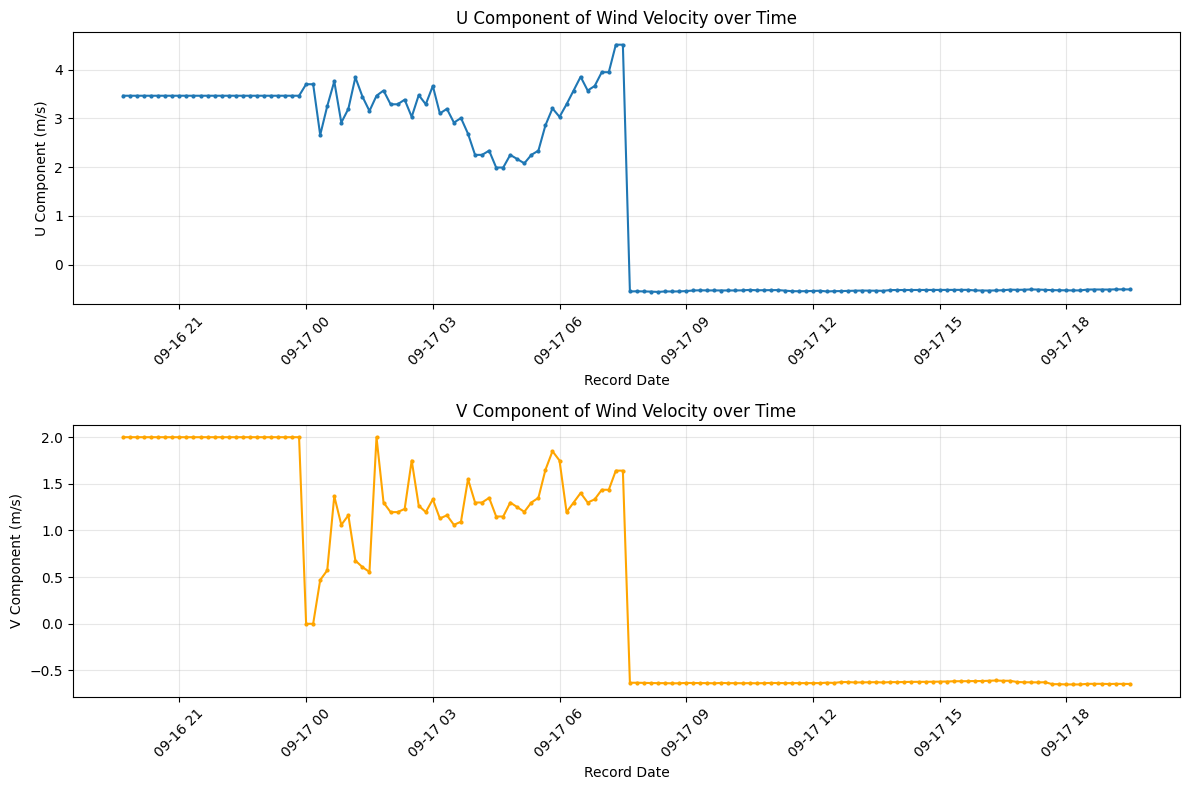

In [16]:
import matplotlib.pyplot as plt

# Create subplots for u and v components
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot u component
ax1.plot(single_station_df['record_date'], single_station_df['u'], marker='o', markersize=2)
ax1.set_title('U Component of Wind Velocity over Time')
ax1.set_xlabel('Record Date')
ax1.set_ylabel('U Component (m/s)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot v component
ax2.plot(single_station_df['record_date'], single_station_df['v'], marker='o', markersize=2, color='orange')
ax2.set_title('V Component of Wind Velocity over Time')
ax2.set_xlabel('Record Date')
ax2.set_ylabel('V Component (m/s)')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [18]:
measurements_df.sort_values(by="record_date", inplace=True, ascending=True)

measurements_df

,station_id,record_date,u,v,is_prediction
0,96,2025-09-16 19:40:00,3.464102,2.000000e+00,False
576,1605,2025-09-16 19:40:00,3.400000,6.245699e-16,False
936,3015,2025-09-16 19:40:00,2.298133,1.928363e+00,False
864,2856,2025-09-16 19:40:00,2.757462,-4.862149e-01,False
792,2794,2025-09-16 19:40:00,3.382893,-1.231273e+00,False
...,...,...,...,...,...
1367,3811,2025-09-17 19:30:00,-0.596016,-7.399438e-01,True
1295,3376,2025-09-17 19:30:00,-0.587593,-7.309487e-01,True
1079,3093,2025-09-17 19:30:00,-0.594093,-7.380517e-01,True
1151,3158,2025-09-17 19:30:00,-0.606727,-7.516816e-01,True


In [19]:
measurements_df.dropna(inplace=True)
measurements_df


,station_id,record_date,u,v,is_prediction
0,96,2025-09-16 19:40:00,3.464102,2.000000e+00,False
576,1605,2025-09-16 19:40:00,3.400000,6.245699e-16,False
936,3015,2025-09-16 19:40:00,2.298133,1.928363e+00,False
864,2856,2025-09-16 19:40:00,2.757462,-4.862149e-01,False
792,2794,2025-09-16 19:40:00,3.382893,-1.231273e+00,False
...,...,...,...,...,...
1367,3811,2025-09-17 19:30:00,-0.596016,-7.399438e-01,True
1295,3376,2025-09-17 19:30:00,-0.587593,-7.309487e-01,True
1079,3093,2025-09-17 19:30:00,-0.594093,-7.380517e-01,True
1151,3158,2025-09-17 19:30:00,-0.606727,-7.516816e-01,True


In [20]:
test_df = measurements_df.copy().sort_values(by="u", inplace=False, ascending=False)
test_df


,station_id,record_date,u,v,is_prediction
1436,3987,2025-09-17 07:00:00,7.976943,1.406550e+00,False
788,1869,2025-09-17 07:00:00,7.583020,1.337091e+00,False
1581,5109,2025-09-17 07:10:00,7.583020,1.337091e+00,False
1970,6106,2025-09-17 00:00:00,7.500000,1.377728e-15,False
1973,6106,2025-09-17 00:30:00,7.400000,1.359358e-15,False
...,...,...,...,...,...
1080,3158,2025-09-17 07:40:00,-0.653999,-7.400392e-01,True
1083,3158,2025-09-17 08:10:00,-0.656074,-7.422746e-01,True
580,1605,2025-09-17 08:20:00,-0.656105,-7.364381e-01,True
436,1001,2025-09-17 08:20:00,-0.656105,-7.365754e-01,True


## Extrapolate u and v to all wind turbines for all intervals

In [21]:
wind_turbines_service = WindTurbinesService(cfg, database_service)

In [22]:
all_wind_turbines_df = wind_turbines_service.load_from_database()

2025-09-17 10:15:16.485 | INFO     | src.wind_turbines.wind_turbines_data_provider:load_from_database:144 - Loaded 4798 wind turbines from database


In [23]:
all_wind_turbines_df.head()

,final_decommission_date,gross_power,hub_height,last_update_date,latitude,longitude,manufacturer,net_nominal_power,rotor_diameter,technology,type_designation,unit_mastr_number
0,None,2000.0,105.0,2023-12-14 09:19:12.317844,52.602453,13.789959,1660.0,2000.0,90.0,691,V90-2MW,SEE985818635128
1,None,2530.0,120.0,2025-06-12 09:17:52.784566,51.892620,13.490910,1597.0,2530.0,120.0,691,GE 2.5-120,SEE954065333897
2,None,3450.0,140.0,2024-10-09 14:40:42.676992,52.361379,14.367995,1660.0,3450.0,112.0,691,V112 3.3/3.45 MW,SEE948721850590
3,None,2000.0,100.0,2024-06-07 15:18:36.556635,52.339744,13.261313,1660.0,2000.0,80.0,691,V-80,SEE992411107808
4,None,2530.0,120.0,2025-02-04 14:52:11.195789,51.890410,13.484510,1597.0,2530.0,120.0,691,GE 2.5-120,SEE933244215582


In [24]:
calculation_service = CalculationService(cfg, database_service, measurement_service, all_wind_turbines_df, weather_stations_df)

In [25]:
extrapolated_measurements_df = calculation_service.extrapolate_u_and_v_to_all_wind_turbines(measurements_df)

In [26]:
extrapolated_measurements_df

,unit_mastr_number,latitude,longitude,manufacturer,type_designation,hub_height,record_date,u,v,is_prediction
0,SEE985818635128,52.602453,13.789959,1660.0,V90-2MW,105.0,2025-09-16 19:40:00,3.751640,0.192533,False
1,SEE954065333897,51.892620,13.490910,1597.0,GE 2.5-120,120.0,2025-09-16 19:40:00,3.469005,-0.061061,False
2,SEE948721850590,52.361379,14.367995,1660.0,V112 3.3/3.45 MW,140.0,2025-09-16 19:40:00,2.182319,0.954419,False
3,SEE992411107808,52.339744,13.261313,1660.0,V-80,100.0,2025-09-16 19:40:00,3.942784,-0.084900,False
4,SEE933244215582,51.890410,13.484510,1597.0,GE 2.5-120,120.0,2025-09-16 19:40:00,3.470354,-0.056002,False
...,...,...,...,...,...,...,...,...,...,...
690907,SEE918240568382,53.086816,14.172692,1660.0,V162-7.2,169.0,2025-09-17 19:30:00,-0.583391,-0.726508,True
690908,SEE995556497261,53.084103,14.170340,1660.0,V162-7.2,169.0,2025-09-17 19:30:00,-0.583409,-0.726527,True
690909,SEE961783448895,53.085005,14.178594,1660.0,V162-7.2,169.0,2025-09-17 19:30:00,-0.583231,-0.726337,True
690910,SEE912922789966,53.105845,14.104210,1001682.0,Nordex N163/6.X,164.0,2025-09-17 19:30:00,-0.585563,-0.728824,True


In [27]:
single_turbine_df = extrapolated_measurements_df[extrapolated_measurements_df["unit_mastr_number"] == "SEE933612141345"]

single_turbine_df

,unit_mastr_number,latitude,longitude,manufacturer,type_designation,hub_height,record_date,u,v,is_prediction
99,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-16 19:40:00,3.494364,-0.065306,False
4897,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-16 19:50:00,3.494364,-0.065306,False
9695,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-16 20:00:00,3.494364,-0.065306,False
14493,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-16 20:10:00,3.494364,-0.065306,False
19291,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-16 20:20:00,3.494364,-0.065306,False
...,...,...,...,...,...,...,...,...,...,...
667021,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-17 18:50:00,-0.578019,-0.715166,True
671819,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-17 19:00:00,-0.577953,-0.717223,True
676617,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-17 19:10:00,-0.572944,-0.715740,True
681415,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-17 19:20:00,-0.572921,-0.715591,True


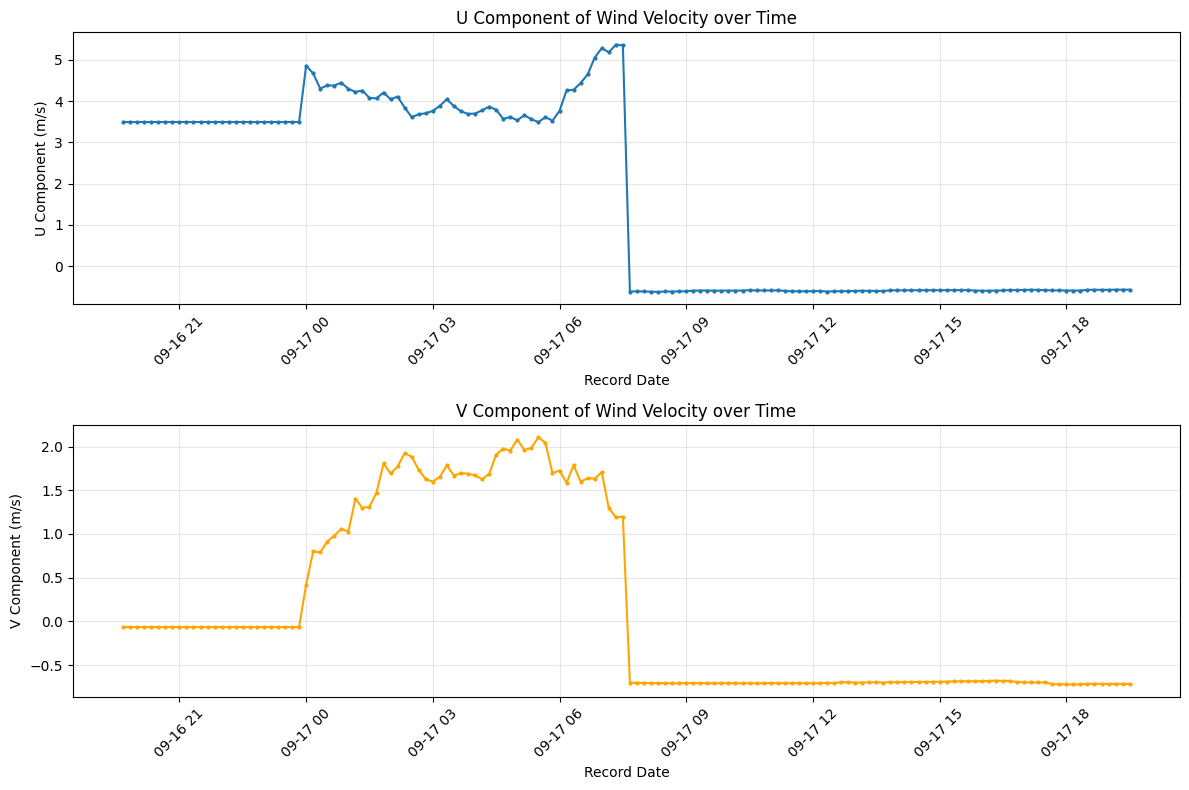

In [28]:
import matplotlib.pyplot as plt

# Create subplots for u and v components
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot u component
ax1.plot(single_turbine_df['record_date'], single_turbine_df['u'], marker='o', markersize=2)
ax1.set_title('U Component of Wind Velocity over Time')
ax1.set_xlabel('Record Date')
ax1.set_ylabel('U Component (m/s)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot v component
ax2.plot(single_turbine_df['record_date'], single_turbine_df['v'], marker='o', markersize=2, color='orange')
ax2.set_title('V Component of Wind Velocity over Time')
ax2.set_xlabel('Record Date')
ax2.set_ylabel('V Component (m/s)')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [29]:
extended_extrapolated_measurements_df = calculation_service.extrapolate_to_hub_height(extrapolated_measurements_df)

In [30]:
extended_extrapolated_measurements_df

,unit_mastr_number,latitude,longitude,manufacturer,type_designation,hub_height,record_date,u,v,is_prediction,wind_speed,hub_height_wind_speed
0,SEE985818635128,52.602453,13.789959,1660.0,V90-2MW,105.0,2025-09-16 19:40:00,3.751640,0.192533,False,3.756577,3.756577
1,SEE954065333897,51.892620,13.490910,1597.0,GE 2.5-120,120.0,2025-09-16 19:40:00,3.469005,-0.061061,False,3.469542,3.469542
2,SEE948721850590,52.361379,14.367995,1660.0,V112 3.3/3.45 MW,140.0,2025-09-16 19:40:00,2.182319,0.954419,False,2.381897,2.381897
3,SEE992411107808,52.339744,13.261313,1660.0,V-80,100.0,2025-09-16 19:40:00,3.942784,-0.084900,False,3.943698,3.943698
4,SEE933244215582,51.890410,13.484510,1597.0,GE 2.5-120,120.0,2025-09-16 19:40:00,3.470354,-0.056002,False,3.470805,3.470805
...,...,...,...,...,...,...,...,...,...,...,...,...
690907,SEE918240568382,53.086816,14.172692,1660.0,V162-7.2,169.0,2025-09-17 19:30:00,-0.583391,-0.726508,True,0.931750,0.931750
690908,SEE995556497261,53.084103,14.170340,1660.0,V162-7.2,169.0,2025-09-17 19:30:00,-0.583409,-0.726527,True,0.931777,0.931777
690909,SEE961783448895,53.085005,14.178594,1660.0,V162-7.2,169.0,2025-09-17 19:30:00,-0.583231,-0.726337,True,0.931517,0.931517
690910,SEE912922789966,53.105845,14.104210,1001682.0,Nordex N163/6.X,164.0,2025-09-17 19:30:00,-0.585563,-0.728824,True,0.934916,0.934916


In [31]:
# max hub_height_wind_speed
extended_extrapolated_measurements_df["hub_height_wind_speed"].max()


np.float64(7.693037475273352)